# Feature Parquet — Inspection (sample 5 dates)

Vérifie le dataset généré par `massive_build_conditional_features.py`.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../code")
sys.path.insert(0, "../code/features")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from feature_catalog import categorize_features
from feature_sets import get_feature_cols, FAMILIES

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

PARQUET = "../data/processed/conditional_features_5min.parquet"
df = pd.read_parquet(PARQUET)

ID_COLS    = {"quote_date","quote_time","quote_dt","option_type","mnes","strategy_id","strategy_family","S"}
feat_cols  = [c for c in df.columns if not c.startswith("target_") and c not in ID_COLS]
tgt_cols   = [c for c in df.columns if c.startswith("target_")]

print(f"Rows : {len(df):,}")
print(f"Cols : {df.shape[1]}  (feat={len(feat_cols)}, target={len(tgt_cols)}, id={df.shape[1]-len(feat_cols)-len(tgt_cols)})")
print(f"Dates: {df['quote_date'].nunique()} ({df['quote_date'].min().date()} → {df['quote_date'].max().date()})")
print(f"Times: {df['quote_time'].nunique()} bars  ({df['quote_time'].min()} → {df['quote_time'].max()})")
print(f"Cross-section: {df.groupby(['option_type','mnes']).ngroups} (strategy×mnes) per slot")

Rows : 4,562,610
Cols : 362  (feat=339, target=15, id=8)
Dates: 992 (2022-04-01 → 2026-05-08)
Times: 72 bars  (10:00 → 15:55)
Cross-section: 64 (strategy×mnes) per slot


In [2]:
df

,quote_date,quote_time,option_type,mnes,quote_dt,S,M,mid,tv,intrinsic,gross_entry_premium,bas,h,fee,rho,d,delta,gamma,vega,theta,iv_mean,n_legs,n_contracts,turnover,snap_error_max,snap_error_mean,abs_mid,premium_abs,net_premium,half_spread_bps,...,strat_vol_lag30_sqtr,strat_vol_lag5_sqtr,strat_vol_lag5_cs_sqtr,strat_vol_since_open_sqtr,vilkov_fDelta_sqtr,vilkov_fDelta_cs_sqtr,vilkov_fDelta_lag30_sqtr,vilkov_fDelta_lag30_signed_sqtr,vilkov_fDelta_signed_sqtr,vilkov_fGamma_sqtr,vilkov_fGamma_cs_sqtr,vilkov_fGamma_lag30_sqtr,vilkov_fGamma_lag30_signed_sqtr,vilkov_fGamma_signed_sqtr,vilkov_fVega_sqtr,vilkov_fVega_cs_sqtr,vilkov_fVega_lag30_sqtr,vilkov_fVega_lag30_signed_sqtr,vilkov_fVega_signed_sqtr,vilkov_txn_sqtr,vilkov_txn_cum_sqtr,vilkov_txn_cum_signed_sqtr,vilkov_txn_signed_sqtr,vilkov_v_sqtr,vilkov_v_cs_sqtr,vilkov_v_cum_sqtr,vilkov_v_cum_signed_sqtr,vilkov_v_lag30_sqtr,vilkov_v_lag30_signed_sqtr,vilkov_v_signed_sqtr
0,2022-04-01,10:00,bear_put_spread,0.975/1,2022-04-01 10:00:00,4539.3500,0.9875,0.0030,0.0029,0.0001,0.0030,0.0002,0.0001,0.0000,0.5292,469.0000,-0.4997,0.0115,0.4520,-25.0166,0.3380,2,2,0.3139,0.0191,0.0167,0.0030,0.0030,0.0030,0.9913,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-04-01,10:00,bear_put_spread,0.975/1.025,2022-04-01 10:00:00,4539.3500,1.0001,0.0257,0.0002,0.0255,0.0257,0.0026,0.0013,0.0000,0.5493,533.0000,-0.9546,0.0009,0.0780,-9.1153,0.4682,2,2,2.6997,0.0477,0.0334,0.0257,0.0257,0.0257,12.7772,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-04-01,10:00,bear_put_spread,0.98/1,2022-04-01 10:00:00,4539.3500,0.9902,0.0030,0.0028,0.0001,0.0031,0.0002,0.0001,0.0000,0.3625,490.0000,-0.4952,0.0112,0.4393,-24.4420,0.3073,2,2,0.3150,0.0317,0.0230,0.0030,0.0030,0.0030,0.9913,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-04-01,10:00,bear_put_spread,0.98/1.02,2022-04-01 10:00:00,4539.3500,1.0001,0.0199,-0.0000,0.0200,0.0200,0.0010,0.0005,0.0000,0.3576,484.0000,NaN,NaN,NaN,NaN,0.3325,2,2,2.0488,0.0317,0.0173,0.0199,0.0199,0.0199,4.9567,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-04-01,10:00,bear_put_spread,0.985/1,2022-04-01 10:00:00,4539.3500,0.9924,0.0029,0.0028,0.0001,0.0031,0.0002,0.0001,0.0000,0.1721,116.0000,-0.4806,0.0102,0.4030,-22.4521,0.2923,2,2,0.3194,0.0278,0.0210,0.0029,0.0029,0.0029,0.9913,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4562605,2026-05-08,15:55,strangle,0.975/1.025,2026-05-08 15:55:00,7397.3875,0.9997,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,905.0000,NaN,NaN,NaN,NaN,NaN,2,2,0.0000,0.0332,0.0323,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,-0.9378,51.9326,0.0000,0.0542,0.0000,0.0000,0.0000,0.0000,-0.9327,0.0000,0.0000,0.0000,0.0000,-0.9323,0.0000,0.0000,0.0000,0.0000,35.6511,35.6511,0.0000,0.0000,-0.9439,67.4611,67.4611,0.0000,0.0000,0.0000
4562606,2026-05-08,15:55,strangle,0.98/1.02,2026-05-08 15:55:00,7397.3875,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,754.0000,NaN,NaN,NaN,NaN,NaN,2,2,0.0000,0.0076,0.0061,0.0000,0.0000,0.0000,0.0000,...,4.0000,0.0000,-0.9378,78.5239,0.0000,0.0542,0.0000,0.0000,0.0000,0.0000,-0.9327,0.0000,0.0000,0.0000,0.0000,-0.9323,0.0000,0.0000,0.0000,1.0000,51.1371,51.1371,1.0000,1.0000,-0.9438,94.8051,94.8051,4.1231,4.1231,1.0000
4562607,2026-05-08,15:55,strangle,0.985/1.015,2026-05-08 15:55:00,7397.3875,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,N

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4562610 entries, 0 to 4562609
Columns: 362 entries, quote_date to vilkov_v_signed_sqtr
dtypes: datetime64[ns](2), float64(325), int64(30), str(5)
memory usage: 12.6 GB


In [11]:
df.isna().mean().sort_values(ascending=False)

abs_delta_to_premium        0.4157
abs_delta_to_premium_sqtr   0.4157
abs_gamma_to_premium_sqtr   0.4157
abs_gamma_to_premium        0.4157
theta_to_premium            0.4157
                             ...  
post_fomc_time              0.0000
pre_fomc_time               0.0000
last_30min_dummy            0.0000
first_30min_dummy           0.0000
quote_date                  0.0000
Length: 362, dtype: float64

In [7]:
df.describe()

,quote_date,quote_dt,S,M,mid,tv,intrinsic,gross_entry_premium,bas,h,fee,rho,d,delta,gamma,vega,theta,iv_mean,n_legs,n_contracts,turnover,snap_error_max,snap_error_mean,abs_mid,premium_abs,net_premium,half_spread_bps,full_spread_bps,fee_bps,abs_delta,...,strat_vol_lag30_sqtr,strat_vol_lag5_sqtr,strat_vol_lag5_cs_sqtr,strat_vol_since_open_sqtr,vilkov_fDelta_sqtr,vilkov_fDelta_cs_sqtr,vilkov_fDelta_lag30_sqtr,vilkov_fDelta_lag30_signed_sqtr,vilkov_fDelta_signed_sqtr,vilkov_fGamma_sqtr,vilkov_fGamma_cs_sqtr,vilkov_fGamma_lag30_sqtr,vilkov_fGamma_lag30_signed_sqtr,vilkov_fGamma_signed_sqtr,vilkov_fVega_sqtr,vilkov_fVega_cs_sqtr,vilkov_fVega_lag30_sqtr,vilkov_fVega_lag30_signed_sqtr,vilkov_fVega_signed_sqtr,vilkov_txn_sqtr,vilkov_txn_cum_sqtr,vilkov_txn_cum_signed_sqtr,vilkov_txn_signed_sqtr,vilkov_v_sqtr,vilkov_v_cs_sqtr,vilkov_v_cum_sqtr,vilkov_v_cum_signed_sqtr,vilkov_v_lag30_sqtr,vilkov_v_lag30_signed_sqtr,vilkov_v_signed_sqtr
count,4562610,4562610,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4391072.0000,4562610.0000,2674725.0000,2674725.0000,2674725.0000,2674725.0000,4196264.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,4562610.0000,2674725.0000,...,4499130.0000,4499130.0000,4497146.0000,4562610.0000,3574329.0000,3571532.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3571496.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3571496.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3572537.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000,3574329.0000
mean,2024-04-12 00:43:19.436373248,2024-04-12 13:40:42.755858176,5169.0083,0.9997,0.0052,0.0003,0.0049,0.0063,0.0001,0.0001,0.0000,0.1785,1907.5955,-0.0720,0.0036,0.0560,-5.1204,0.3532,2.3124,2.7188,0.6414,0.0447,0.0303,0.0057,0.0057,0.0052,0.6453,1.2906,0.0821,0.4259,...,61.8500,25.0807,-0.0747,150.3419,33.3014,-0.0319,56.3008,-755.5908,-314.4824,173569.0069,-0.0596,411353.7577,122297.0276,55376.2136,132.9894,-0.0592,332.2745,69.6242,30.1557,15.7931,92.4785,-0.1357,1.3311,27.4490,-0.0719,161.8191,-6.6415,67.6716,1.5625,1.4564
min,2022-04-01 00:00:00,2022-04-01 10:00:00,3529.6250,0.9811,-0.0187,-0.0183,-0.0015,0.0000,0.0000,0.0000,0.0000,0.0005,3.0000,-0.9964,-0.1632,-1.4643,-2365.1505,0.0000,2.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0187,0.0000,0.0000,0.0405,0.0000,...,0.0000,0.0000,-1.4477,0.0000,-102986.3791,-2.3602,-136551.0298,-204008.4555,-128418.5007,0.0000,-1.4648,0.0000,-5709771.7308,-4010827.1655,0.0000,-1.4693,0.0000,-1902.5057,-1551.6028,0.0000,0.0000,-435.0690,-126.4555,0.0000,-1.4943,0.0000,-727.1678,0.0000,-355.4757,-223.8124
25%,2023-04-11 00:00:00,2023-04-11 14:10:00,4156.2500,0.9997,0.0002,-0.0000,0.0000,0.0010,0.0000,0.0000,0.0000,0.0224,652.0000,-0.4616,-0.0019,-0.0647,-19.5893,0.2230,2.0000,2.0000,0.0991,0.0255,0.0177,0.0008,0.0008,0.0002,0.1685,0.3370,0.0590,0.0869,...,30.1993,10.7238,-0.9354,71.0774,-6825.4502,-0.6936,-15857.1646,-14876.9348,-6411.9323,19067.6555,-0.9474,57261.0775,-100253.1023,-37122.5579,20.8339,-0.9489,63.6384,-116.0878,-40.9446,6.5574,40.1248,-51.4393,-8.5440,11.8322,-0.9314,76.0723,-96.3068,33.0606,-40.8412,-16.1555
50%,2024-04-09 00:00:00,2024-04-09 13:50:00,5147.7250,1.0000,0.0016,0.0000,0.0001,0.0025,0.0001,0.0000,0.0000,0.0845,1449.0000,-0.0243,0.0005,0.0171,-2.6232,0.3099,2.0000,3.0000,0.2528,0.0355,0.0254,0.0019,0.0019,0.0016,0.3470,0.6939,0.0753,0.4282,...,61.2617,24.1247,-0.4303,137.2188,0.0000,-0.2168,-631.0060,297.3283,0.0000,119421.3693,-0.3984,297420.2001,0.0000,0.0000,116.1832,-0.3939,306.1422,0.0000,0.0000,14.5945,80.2185,-14.0712,0.0000,25.7488,-0.4226,142.7831,-29.7993,65.3070,-5.2915,0.0000
75%,2025-04-09 00:00:00,2025-04-09 15:25:00,5997.0250,1.0003,0.0089,0.0011,0.0097,0.0102,0.0001,0.0001,0.0000,0.2988,2680.0000,0.3216,0.0114,0.2356,8.8981,0.4240,2.0000,3.0000,1.0258,

## 1. Catégories preprocesseur

In [8]:
cat = categorize_features(feat_cols)
uncategorized = [c for c in feat_cols if not any(c in v for v in cat.values())]

summary = pd.DataFrame({
    "Catégorie": ["ts (market-level, z-score)", "cs (déjà normalisé)", "dummy (0/1)", "raw (winsor seulement)", "non catégorisé"],
    "N features": [len(cat["ts"]), len(cat["cs"]), len(cat["dummies"]), len(cat["raw"]), len(uncategorized)],
    "Traitement preprocesseur": [
        "winsor + z-score (training window)",
        "winsor légère seulement",
        "fill NaN→0, pass-through",
        "winsor seulement",
        "⚠ raw + warning",
    ]
})
display(summary.set_index("Catégorie"))


,N features,Traitement preprocesseur
Catégorie,,
"ts (market-level, z-score)",72,winsor + z-score (training window)
cs (déjà normalisé),46,winsor légère seulement
dummy (0/1),34,"fill NaN→0, pass-through"
raw (winsor seulement),187,winsor seulement
non catégorisé,0,⚠ raw + warning


In [14]:
# ── TS — market-level (winsor + z-score) ─────────────────────────────────────
ts_cols_cat = cat["ts"]
print(f"TS — {len(ts_cols_cat)} features  (même valeur pour toutes les stratégies à une date×time donnée)")
print("Preprocessing : winsor [1%-99%] + z-score (training window uniquement)\n")

_ts_stats = df[ts_cols_cat].agg(["mean", "std", "min", "max"]).T.round(5)
_ts_stats["nan%"] = (df[ts_cols_cat].isna().mean() * 100).round(1)
display(_ts_stats.sort_values("nan%"))

TS — 72 features  (même valeur pour toutes les stratégies à une date×time donnée)
Preprocessing : winsor [1%-99%] + z-score (training window uniquement)



,mean,std,min,max,nan%
spx_ret_since_1000,0.0000,0.0058,-0.0657,0.0848,0.0000
slope_dn,9.9926,7.6711,-30.6913,91.3566,0.0000
expected_move_pct,0.0048,0.0029,0.0000,0.0313,0.0000
spx_dist_from_low,0.0034,0.0041,0.0000,0.1034,0.0000
spx_dist_from_high,-0.0031,0.0040,-0.0662,0.0000,0.0000
...,...,...,...,...,...
aft_d30_left_tail_richness,-0.0016,0.0101,-0.2343,0.2459,10.3000
aft_isolated_right_tail_shift,-0.0068,0.0359,-0.6458,0.7120,10.3000
aft_d30_tail_imbalance,-0.0016,0.0162,-0.3911,0.3902,10.7000
opt_iv_1020,0.5162,0.3169,0.0000,3.6174,17.7000


In [15]:
# ── CS — cross-sectionnellement normalisé au build time (winsor léger) ────────
cs_cols_cat = cat["cs"]
print(f"CS — {len(cs_cols_cat)} features  (déjà z-scorés cross-sectionnellement)")
print("Preprocessing : winsor léger [0.5%-99.5%] seulement  (mean≈0, std≈1 par construction)")
print("Inclut : *_cs, *_cs_all, *_cs_family, *_timeslot_z\n")

_cs_stats = df[cs_cols_cat].agg(["mean", "std", "min", "max"]).T.round(5)
_cs_stats["nan%"] = (df[cs_cols_cat].isna().mean() * 100).round(1)
display(_cs_stats.sort_values("nan%"))

CS — 46 features  (déjà z-scorés cross-sectionnellement)
Preprocessing : winsor léger [0.5%-99.5%] seulement  (mean≈0, std≈1 par construction)
Inclut : *_cs, *_cs_all, *_cs_family, *_timeslot_z



,mean,std,min,max,nan%
M_cs,-0.0000,0.9921,-3.6132,3.1490,0.0000
tv_cs,0.0000,0.9921,-3.4533,4.0354,0.0000
mid_cs,0.0000,0.9921,-2.4080,3.4244,0.0000
h_cs,-0.0000,0.9921,-2.2454,5.5117,0.0000
gross_entry_premium_cs,0.0000,0.9921,-2.0662,3.4336,0.0000
d_cs,-0.0000,0.9921,-2.3451,6.9303,0.0000
pnl_short_lag1_same_time_cs,0.0000,0.9921,-4.6421,4.6104,0.1000
pnl_lag1_same_time_cs,0.0000,0.9921,-4.6421,4.6620,0.1000
pnl_short_lag2_same_time_cs,0.0000,0.9921,-5.1023,4.6922,0.2000
pnl_std5_same_time_cs,-0.0000,0.9921,-2.2186,4.5201,0.2000


In [16]:
# ── Raw — strategy-specific (winsor seulement) ───────────────────────────────
raw_cols_cat = cat["raw"]
print(f"Raw — {len(raw_cols_cat)} features  (strategy-specific, échelle brute)")
print("Preprocessing : winsor [1%-99%] seulement")
print("Inclut : pnl_lag*, vilkov_v*, strat_vol_*, greeks, payoff shape, bar_index, ...\n")

_raw_stats = df[raw_cols_cat].agg(["mean", "std", "min", "max"]).T.round(5)
_raw_stats["nan%"] = (df[raw_cols_cat].isna().mean() * 100).round(1)
display(_raw_stats.sort_values("nan%"))

Raw — 187 features  (strategy-specific, échelle brute)
Preprocessing : winsor [1%-99%] seulement
Inclut : pnl_lag*, vilkov_v*, strat_vol_*, greeks, payoff shape, bar_index, ...



,mean,std,min,max,nan%
M,0.9998,0.0054,0.9811,1.0176,0.0000
ps_min_payoff,-0.0469,0.0576,-0.1450,0.0000,0.0000
ps_max_payoff,0.0383,0.0467,0.0000,0.1500,0.0000
T_years_approx,0.0019,0.0011,0.0001,0.0037,0.0000
minute,27.4891,17.2587,0.0000,55.0000,0.0000
...,...,...,...,...,...
abs_gamma_to_premium,60289.6433,127305.8679,0.0003,6773885.1187,41.6000
abs_gamma_to_premium_sqtr,177.0704,170.1050,0.0178,2602.6689,41.6000
abs_delta_to_premium,328.3659,1403.3798,0.0000,89303.6774,41.6000
abs_delta_to_premium_sqtr,13.5191,12.0665,0.0037,298.8372,41.6000


In [17]:
# ── Dummy — indicateurs binaires (pass-through) ──────────────────────────────
dum_cols_cat = cat["dummies"]
print(f"Dummy — {len(dum_cols_cat)} features  (0/1, NaN→0, aucune normalisation)")
print("Inclut : strat_family_*, is_*, first/last_30min_dummy, flow_all_legs_matched, ...\n")

_dum_stats = df[dum_cols_cat].agg(["mean", "std", "min", "max"]).T.round(5)
_dum_stats["nan%"]       = (df[dum_cols_cat].isna().mean() * 100).round(1)
_dum_stats["positive_%"] = (_dum_stats["mean"] * 100).round(1)
display(_dum_stats[["positive_%", "nan%", "std", "min", "max"]].sort_values("positive_%", ascending=False))

Dummy — 34 features  (0/1, NaN→0, aucune normalisation)
Inclut : strat_family_*, is_*, first/last_30min_dummy, flow_all_legs_matched, ...



,positive_%,nan%,std,min,max
flow_all_legs_matched,78.3000,0.0000,0.4119,0.0000,1.0000
all_liquid_int,60.8000,0.0000,0.4882,0.0000,1.0000
illiquid_dummy,39.2000,0.0000,0.4882,0.0000,1.0000
strat_family_directional_spread,31.3000,0.0000,0.4635,0.0000,1.0000
strat_family_ratio_spread,31.3000,0.0000,0.4635,0.0000,1.0000
lunchtime_dummy,26.4000,0.0000,0.4408,0.0000,1.0000
strat_bear_put_spread,15.6000,0.0000,0.3632,0.0000,1.0000
strat_bull_call_spread,15.6000,0.0000,0.3630,0.0000,1.0000
strat_call_ratio_spread,15.6000,0.0000,0.3630,0.0000,1.0000
strat_put_ratio_spread,15.6000,0.0000,0.3632,0.0000,1.0000


## 2. Missingness — vue globale

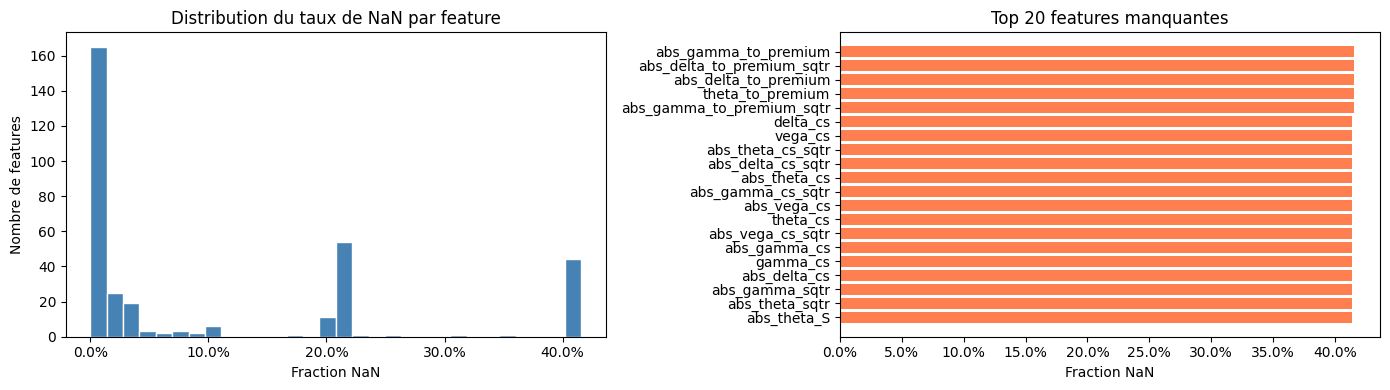

Features à 0% NaN   : 119
Features à 100% NaN : 0  ← timeslot_z (normal avec 5 dates, min_obs=30)
Features partielles  : 220

Note: Sur le dataset complet (992 dates):
  - timeslot_z seront remplis après les 30 premières dates de chaque slot
  - pnl_lag2/lag3 NaN < 1%  (seulement les 2-3 premières dates)
  - abs_*_to_premium 37% NaN → stratégies OTM avec mid≈0 (correct)


In [18]:
miss = df[feat_cols].isna().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution du % de NaN
axes[0].hist(miss.values, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Fraction NaN")
axes[0].set_ylabel("Nombre de features")
axes[0].set_title("Distribution du taux de NaN par feature")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Top 20 features avec le plus de NaN
top20 = miss.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color="coral")
axes[1].set_xlabel("Fraction NaN")
axes[1].set_title("Top 20 features manquantes")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# Explication
n_zero = (miss == 0).sum()
n_full = (miss == 1.0).sum()
n_partial = ((miss > 0) & (miss < 1)).sum()
print(f"Features à 0% NaN   : {n_zero}")
print(f"Features à 100% NaN : {n_full}  ← timeslot_z (normal avec 5 dates, min_obs=30)")
print(f"Features partielles  : {n_partial}")

# Note sur le full dataset
print("\nNote: Sur le dataset complet (992 dates):")
print("  - timeslot_z seront remplis après les 30 premières dates de chaque slot")
print("  - pnl_lag2/lag3 NaN < 1%  (seulement les 2-3 premières dates)")
print("  - abs_*_to_premium 37% NaN → stratégies OTM avec mid≈0 (correct)")

## 3. Targets — distributions et taux positifs

In [6]:
# ── Stats globales des targets ─────────────────────────────────────────────────
tgt_stats = []
for t in tgt_cols:
    col = df[t].dropna()
    is_binary = bool(col.isin([0.0, 1.0]).all()) and (col.nunique() <= 2)
    tgt_stats.append({
        "target": t.replace("target_y_", ""),
        "type":       "binary" if is_binary else "continuous",
        "N":          int(col.count()),
        "mean":       col.mean(),
        "std":        col.std(),
        "pos_rate%":  (col > 0).mean() * 100,
        "NaN%":       df[t].isna().mean() * 100,
    })

tgt_df = pd.DataFrame(tgt_stats).set_index("target")
display(tgt_df.round(4))

_bin_tgts  = [f"target_y_{n}" for n, r in tgt_df.iterrows() if r["type"] == "binary"]
_cont_tgts = [f"target_y_{n}" for n, r in tgt_df.iterrows() if r["type"] == "continuous"]
print(f"\nBinaires  ({len(_bin_tgts)}) : {_bin_tgts}")
print(f"Continues ({len(_cont_tgts)}) : {_cont_tgts}")

,type,N,mean,std,pos_rate%,NaN%
target,,,,,,
long_net,continuous,4562610,-0.0001,0.0033,41.7906,0.0000
short_net,continuous,4562610,-0.0001,0.0033,51.6533,0.0000
long_gross,continuous,4562610,-0.0000,0.0033,43.3551,0.0000
short_gross,continuous,4562610,0.0000,0.0033,52.6987,0.0000
long_minus_short_net,continuous,4562610,-0.0000,0.0065,43.3551,0.0000
best_side_net,continuous,4562610,0.0019,0.0026,93.4439,0.0000
long_profitable,binary,4562610,0.4179,0.4932,41.7906,0.0000
short_profitable,binary,4562610,0.5165,0.4997,51.6533,0.0000
best_direction,continuous,4562610,-0.1329,0.9911,43.3551,0.0000



Binaires  (6) : ['target_y_long_profitable', 'target_y_short_profitable', 'target_y_long_above_median', 'target_y_short_above_median', 'target_y_long_above_cs_mean', 'target_y_short_above_cs_mean']
Continues (9) : ['target_y_long_net', 'target_y_short_net', 'target_y_long_gross', 'target_y_short_gross', 'target_y_long_minus_short_net', 'target_y_best_side_net', 'target_y_best_direction', 'target_y_long_cs_rank', 'target_y_short_cs_rank']


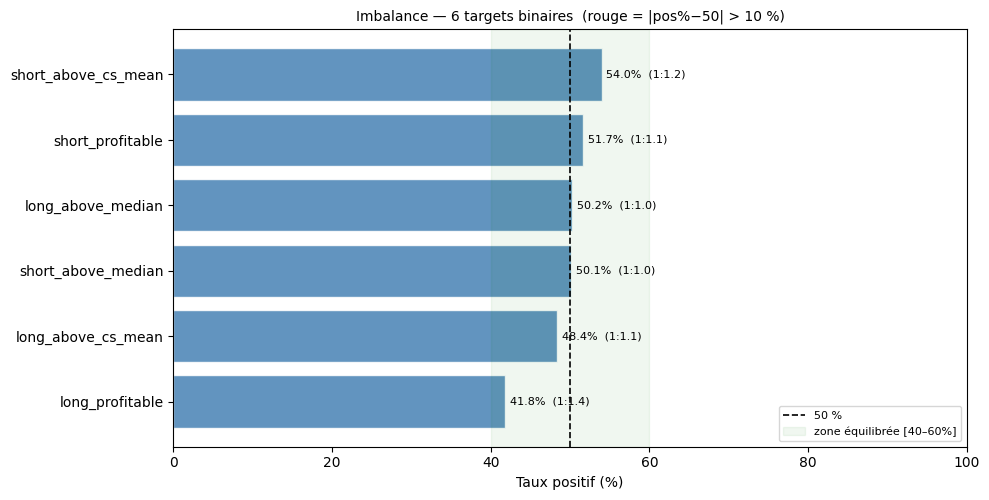

,N,N_pos (1),N_neg (0),pos%,imbalance_ratio,imbalancé?
target,,,,,,
long_profitable,4562610,1906743,2655867,41.7900,1.3900,False
long_above_cs_mean,4562610,2208645,2353965,48.4100,1.0700,False
short_above_median,4562610,2287790,2274820,50.1400,1.0100,False
long_above_median,4562610,2291570,2271040,50.2200,1.0100,False
short_profitable,4562610,2356740,2205870,51.6500,1.0700,False
short_above_cs_mean,4562610,2463240,2099370,53.9900,1.1700,False


In [7]:
# ── Imbalance — targets binaires ─────────────────────────────────────────────
if not _bin_tgts:
    print("Aucun target binaire.")
else:
    _pos  = {t.replace("target_y_", ""): df[t].mean() * 100    for t in _bin_tgts}
    _n1   = {t.replace("target_y_", ""): int(df[t].sum())      for t in _bin_tgts}
    _ntot = {t.replace("target_y_", ""): int(df[t].count())    for t in _bin_tgts}

    _names = sorted(_pos, key=_pos.get)
    _rates = [_pos[n] for n in _names]

    fig, ax = plt.subplots(figsize=(10, 0.55 * len(_names) + 1.8))
    _colors = ["tomato" if abs(r - 50) > 10 else "steelblue" for r in _rates]
    _bars   = ax.barh(_names, _rates, color=_colors, edgecolor="white", alpha=0.85)
    ax.axvline(50, color="black", lw=1.2, linestyle="--", label="50 %")
    ax.axvspan(40, 60, alpha=0.06, color="green", label="zone équilibrée [40–60%]")

    for bar, name, val in zip(_bars, _names, _rates):
        n1 = _n1[name]; n = _ntot[name]; n0 = n - n1
        ratio = max(n1, n0) / max(min(n1, n0), 1)
        ax.text(min(val + 0.6, 90), bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%  (1:{ratio:.1f})", va="center", fontsize=8)

    ax.set_xlabel("Taux positif (%)")
    ax.set_xlim(0, 100)
    ax.set_title(
        f"Imbalance — {len(_bin_tgts)} targets binaires  "
        f"(rouge = |pos%−50| > 10 %)",
        fontsize=10
    )
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()

    # Table résumé
    _rows = []
    for t in sorted(_bin_tgts):
        name = t.replace("target_y_", "")
        n1 = _n1[name]; n = _ntot[name]; n0 = n - n1
        _rows.append({
            "target":          name,
            "N":               n,
            "N_pos (1)":       n1,
            "N_neg (0)":       n0,
            "pos%":            round(_pos[name], 2),
            "imbalance_ratio": round(max(n1, n0) / max(min(n1, n0), 1), 2),
            "imbalancé?":      abs(_pos[name] - 50) > 10,
        })
    display(pd.DataFrame(_rows).set_index("target").sort_values("pos%"))

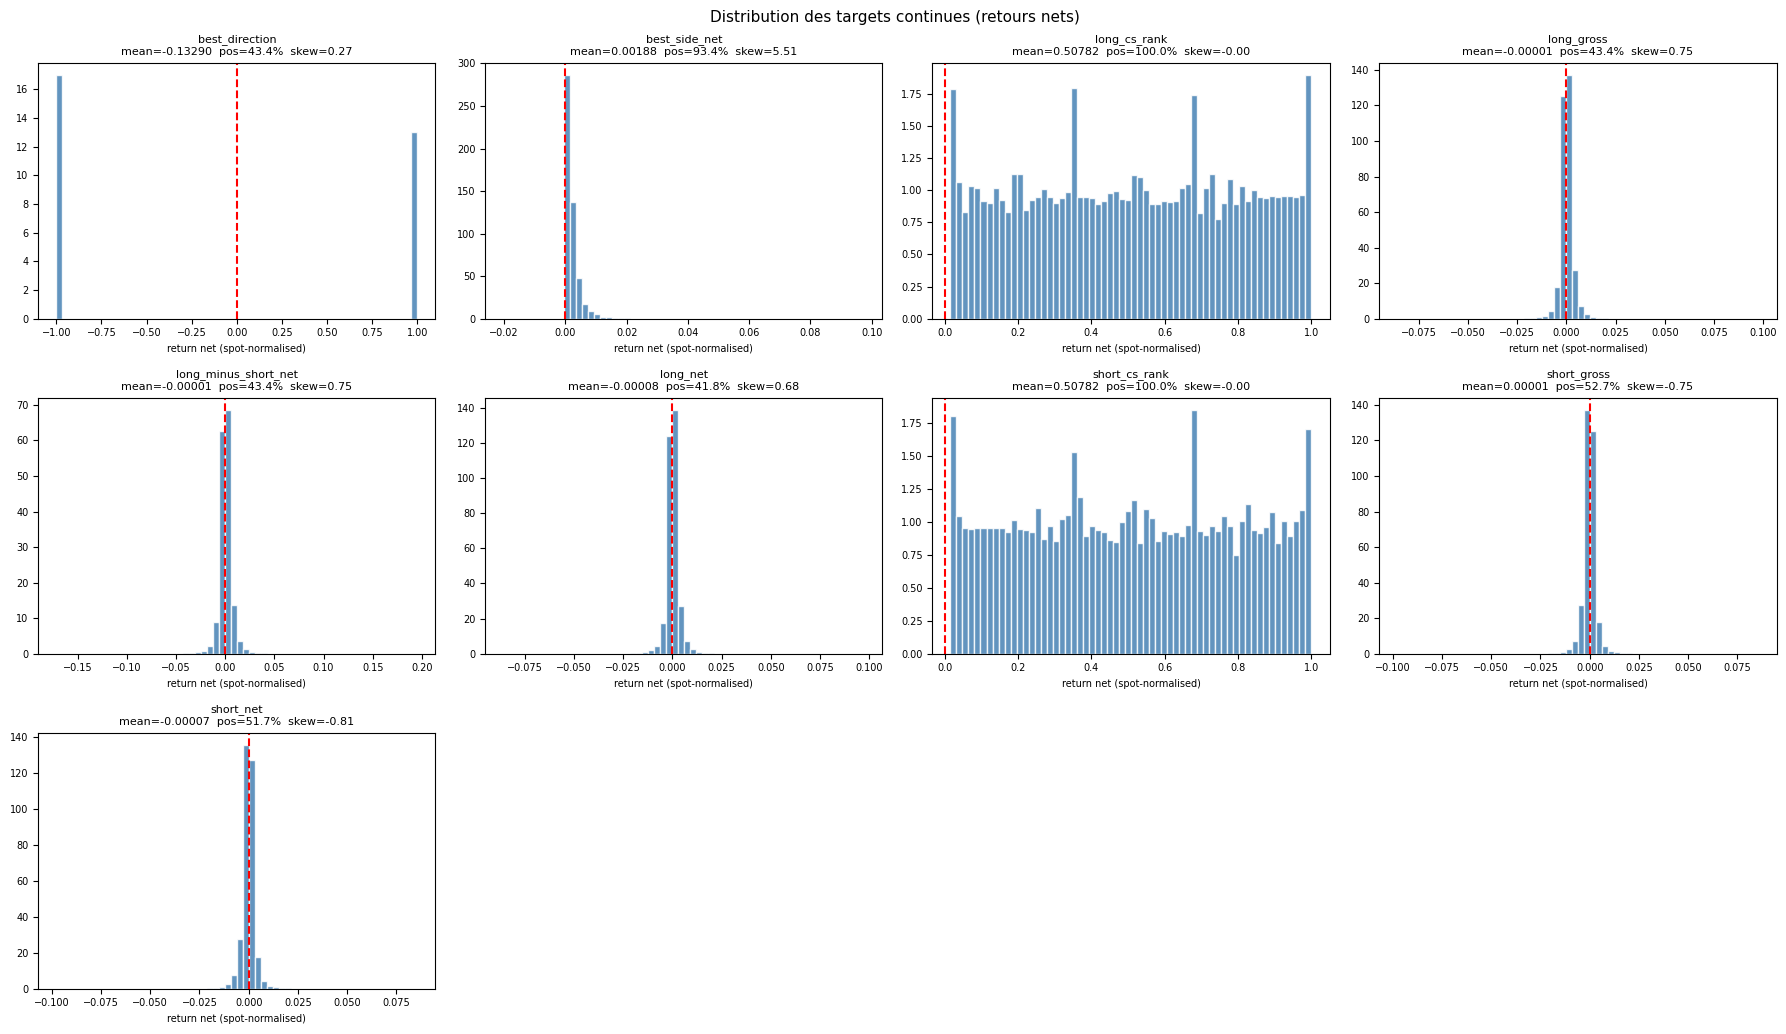

In [8]:
# ── Distribution des targets continues ────────────────────────────────────────
if _cont_tgts:
    n_cont = len(_cont_tgts)
    cols_per_row = min(n_cont, 4)
    n_rows = (n_cont + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row,
                             figsize=(4.5 * cols_per_row, 3.5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for i, t in enumerate(sorted(_cont_tgts)):
        ax = axes_flat[i]
        data = df[t].dropna()
        ax.hist(data, bins=60, color="steelblue", edgecolor="white", density=True, alpha=0.85)
        ax.axvline(0, color="red", lw=1.5, linestyle="--")
        pos = (data > 0).mean() * 100
        skew = float(data.skew())
        ax.set_title(f"{t.replace('target_y_','')}\nmean={data.mean():.5f}  pos={pos:.1f}%  skew={skew:.2f}",
                     fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_xlabel("return net (spot-normalised)", fontsize=7)

    for ax in axes_flat[len(_cont_tgts):]:
        ax.set_visible(False)

    plt.suptitle("Distribution des targets continues (retours nets)", fontsize=11)
    plt.tight_layout()
    plt.show()

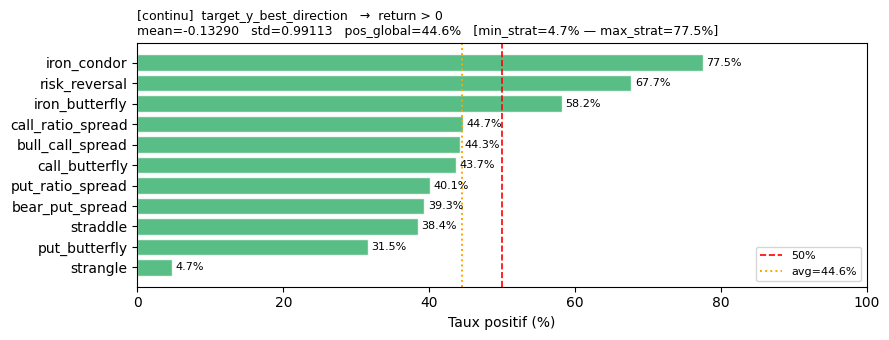

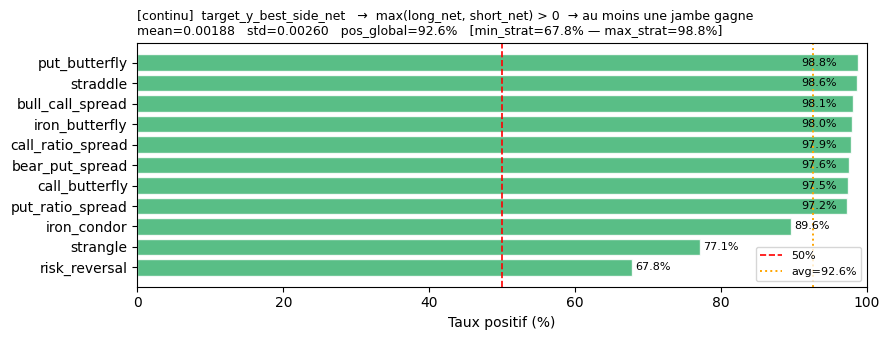

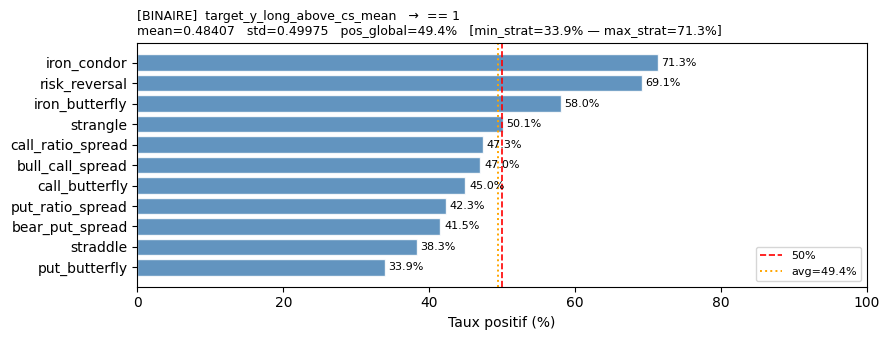

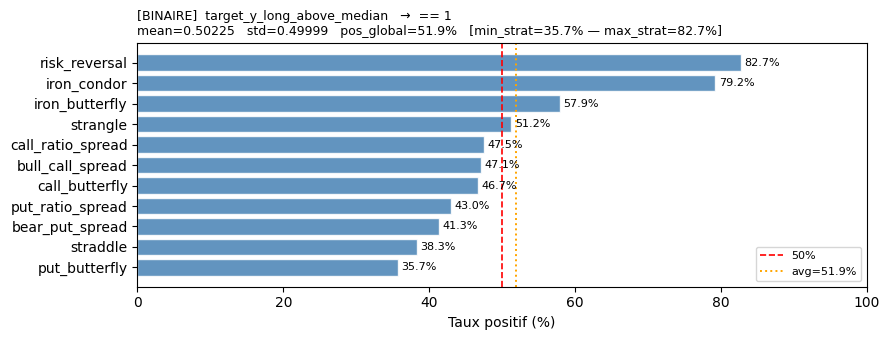

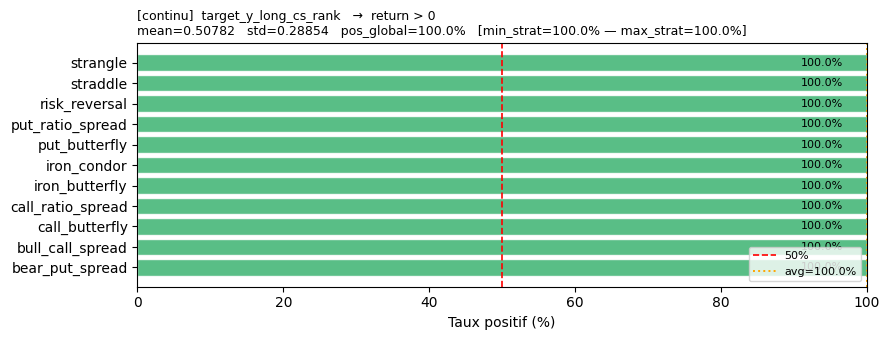

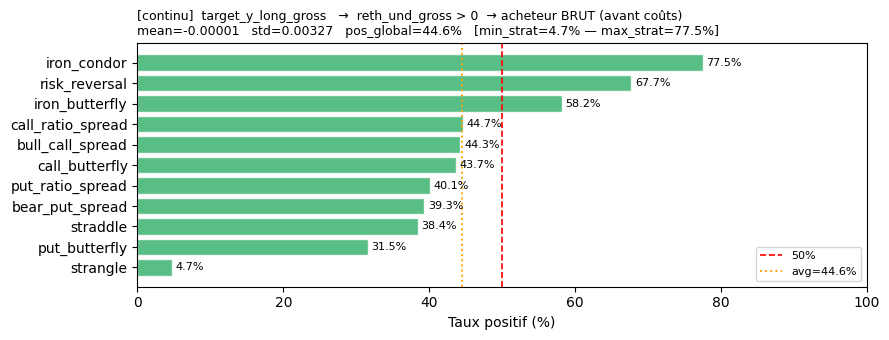

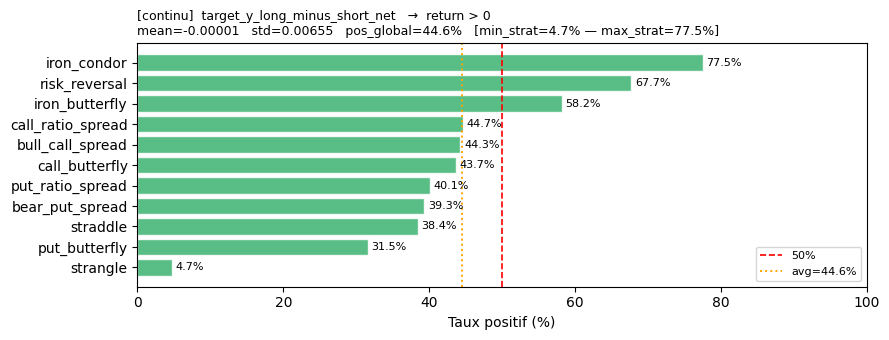

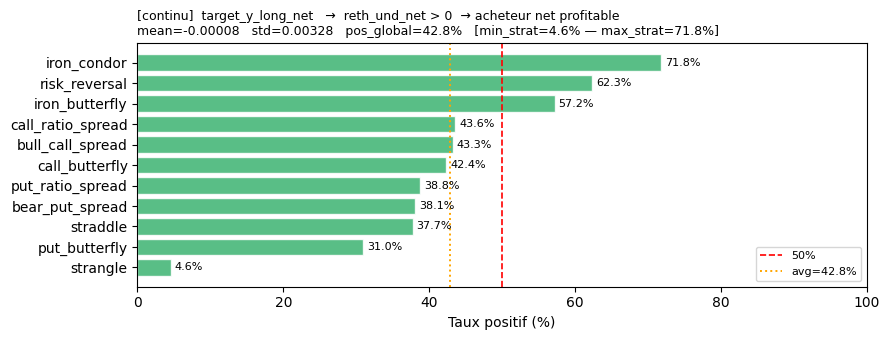

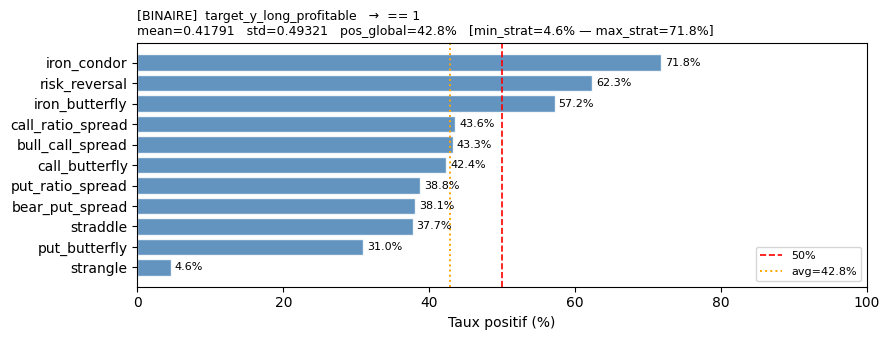

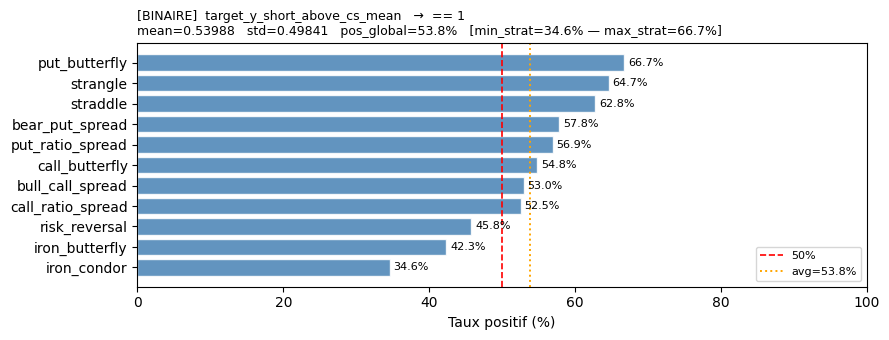

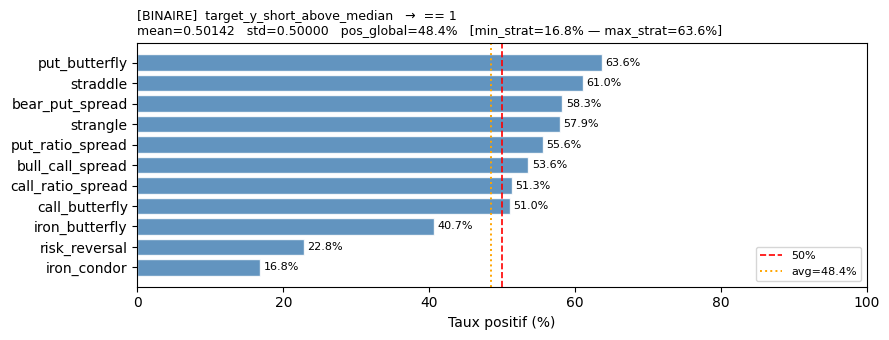

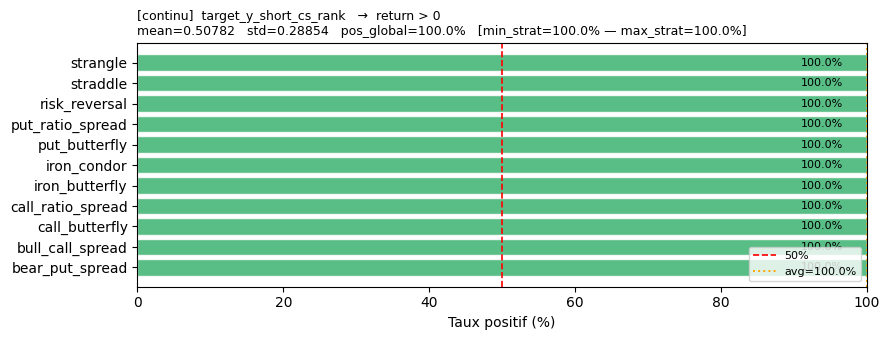

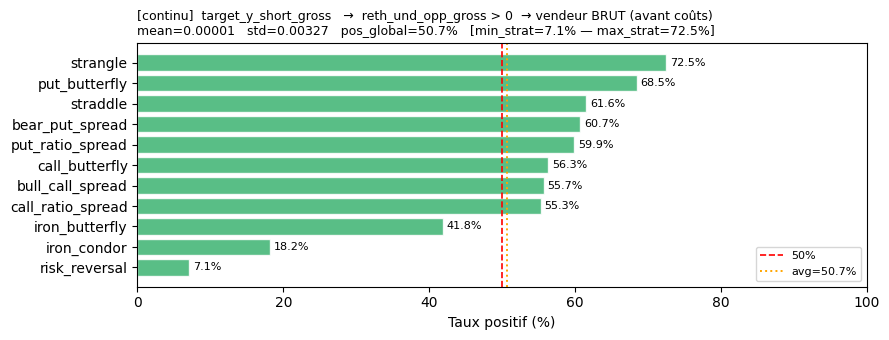

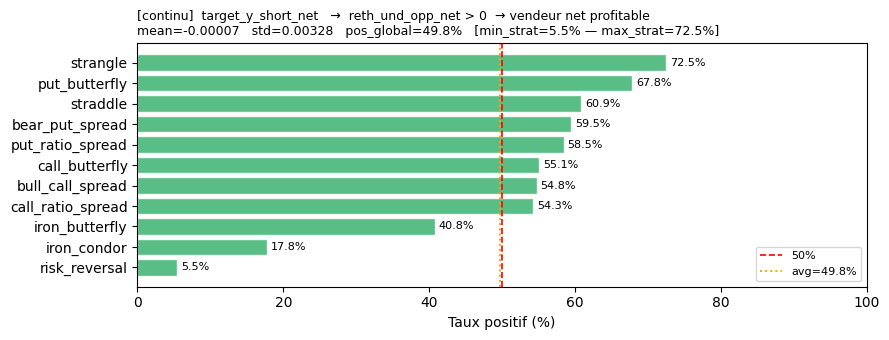

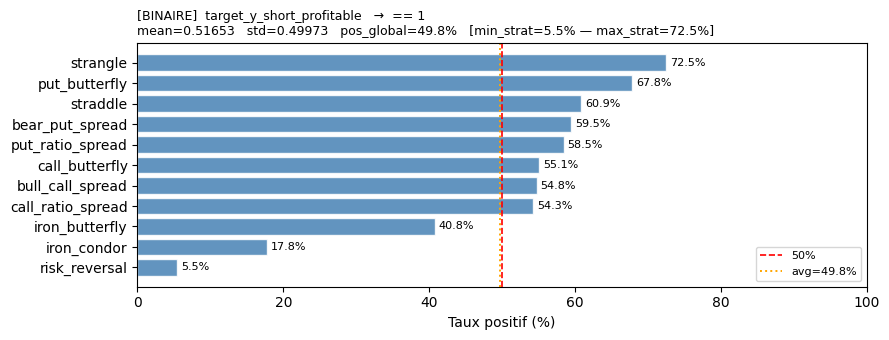

In [9]:
# ── Taux positif par stratégie — UNE FIGURE PAR TARGET ───────────────────────
#
# "Positif" défini précisément pour chaque target :
#   long_net      → reth_und_net > 0         (return NET de coûts, côté acheteur)
#   short_net     → reth_und_opp_net > 0     (return NET, côté vendeur = opp)
#   best_side_net → max(long, short) net > 0  (meilleure jambe)
#   *_gross       → même chose AVANT coûts de transaction
#   *_rv_*        → return > médiane cross-section (target valeur-relative)
#   *_binary      → indicateur 0/1 précalculé

_DESCRIPTIONS = {
    "long_net":       "reth_und_net > 0  → acheteur net profitable",
    "short_net":      "reth_und_opp_net > 0  → vendeur net profitable",
    "best_side_net":  "max(long_net, short_net) > 0  → au moins une jambe gagne",
    "long_gross":     "reth_und_gross > 0  → acheteur BRUT (avant coûts)",
    "short_gross":    "reth_und_opp_gross > 0  → vendeur BRUT (avant coûts)",
    "rv_long":        "long_net > médiane cross-section → valeur relative long",
    "rv_short":       "short_net > médiane cross-section → valeur relative short",
    "rv_best":        "best_net > médiane cross-section → valeur relative best",
}

for t in sorted(tgt_cols):
    name  = t.replace("target_y_", "")
    col   = df[t].dropna()
    is_bin = bool(col.isin([0.0, 1.0]).all()) and (col.nunique() <= 2)
    desc  = _DESCRIPTIONS.get(name, "== 1" if is_bin else "return > 0")

    # Rate par stratégie
    if is_bin:
        rates = df.groupby("option_type")[t].mean() * 100
    else:
        rates = df.groupby("option_type")[t].apply(lambda g: (g > 0).mean() * 100)
    rates = rates.sort_values()

    fig, ax = plt.subplots(figsize=(9, 3.5))
    color = "steelblue" if is_bin else "mediumseagreen"
    bars = ax.barh(rates.index, rates.values, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(50,           color="red",    lw=1.2, linestyle="--", label="50%")
    ax.axvline(rates.mean(), color="orange", lw=1.4, linestyle=":",
               label=f"avg={rates.mean():.1f}%")
    ax.set_xlabel("Taux positif (%)")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8, loc="lower right")

    ttype = "BINAIRE" if is_bin else "continu"
    ax.set_title(
        f"[{ttype}]  target_y_{name}   →  {desc}\n"
        f"mean={col.mean():.5f}   std={col.std():.5f}   "
        f"pos_global={rates.mean():.1f}%   "
        f"[min_strat={rates.min():.1f}% — max_strat={rates.max():.1f}%]",
        fontsize=9, loc="left"
    )
    for bar, val in zip(bars, rates.values):
        ax.text(min(val + 0.5, 91), bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

## 4. Features clés — valeurs à 10:00 par stratégie

In [21]:
d10 = df[df["quote_time"] == "10:00"].copy()

key_feats = [
    "mid", "h", "rho", "d",
    "delta", "gamma_S", "vega_S",
    "ivar_0dte", "atm_iv", "slope_dn",
    "aft_atm_iv", "aft_left_tail_richness", "aft_tail_imbalance",
    "ps_max_profit", "ps_dist_be",
]
key_feats = [f for f in key_feats if f in d10.columns]

# Moyenne par stratégie type
pivot = (
    d10.groupby("option_type")[key_feats]
    .mean()
    .T
)
pivot

option_type,bear_put_spread,bull_call_spread,call_butterfly,call_ratio_spread,iron_butterfly,iron_condor,put_butterfly,put_ratio_spread,risk_reversal,straddle,strangle
mid,0.0086,0.0088,0.0029,0.0085,-0.0048,-0.0010,0.0017,0.0082,-0.0001,0.0057,0.0008
h,0.0002,0.0002,0.0002,0.0002,0.0001,0.0001,0.0001,0.0002,0.0000,0.0001,0.0000
rho,0.1192,0.1047,0.2223,0.1893,0.2029,0.2351,0.2520,0.2166,0.1894,0.0340,0.1894
d,619.4306,824.7488,1393.2453,1609.8272,1433.6815,1614.6717,1577.0948,1200.0103,1365.5554,108.0010,1365.5554
delta,-0.5889,0.5911,0.1064,0.4960,-0.0272,-0.0043,-0.2661,-0.4940,0.2099,0.0028,-0.0230
gamma_S,26.9086,21.7210,-37.3561,2.2636,-74.5539,-36.6029,22.4813,9.5927,-1.8618,134.0625,40.1910
vega_S,0.0000,0.0000,-0.0001,0.0000,-0.0001,-0.0001,0.0000,-0.0000,-0.0000,0.0002,0.0001
ivar_0dte,6.3038,6.3014,6.3014,6.3014,6.3014,6.3014,6.3014,6.3038,6.3014,6.3014,6.3014
atm_iv,0.2713,0.2712,0.2712,0.2712,0.2712,0.2712,0.2712,0.2713,0.2712,0.2712,0.2712
slope_dn,4.5647,4.5655,4.5655,4.5655,4.5655,4.5655,4.5655,4.5647,4.5655,4.5655,4.5655


## 5. Intraday — évolution d'une feature market-level sur la journée

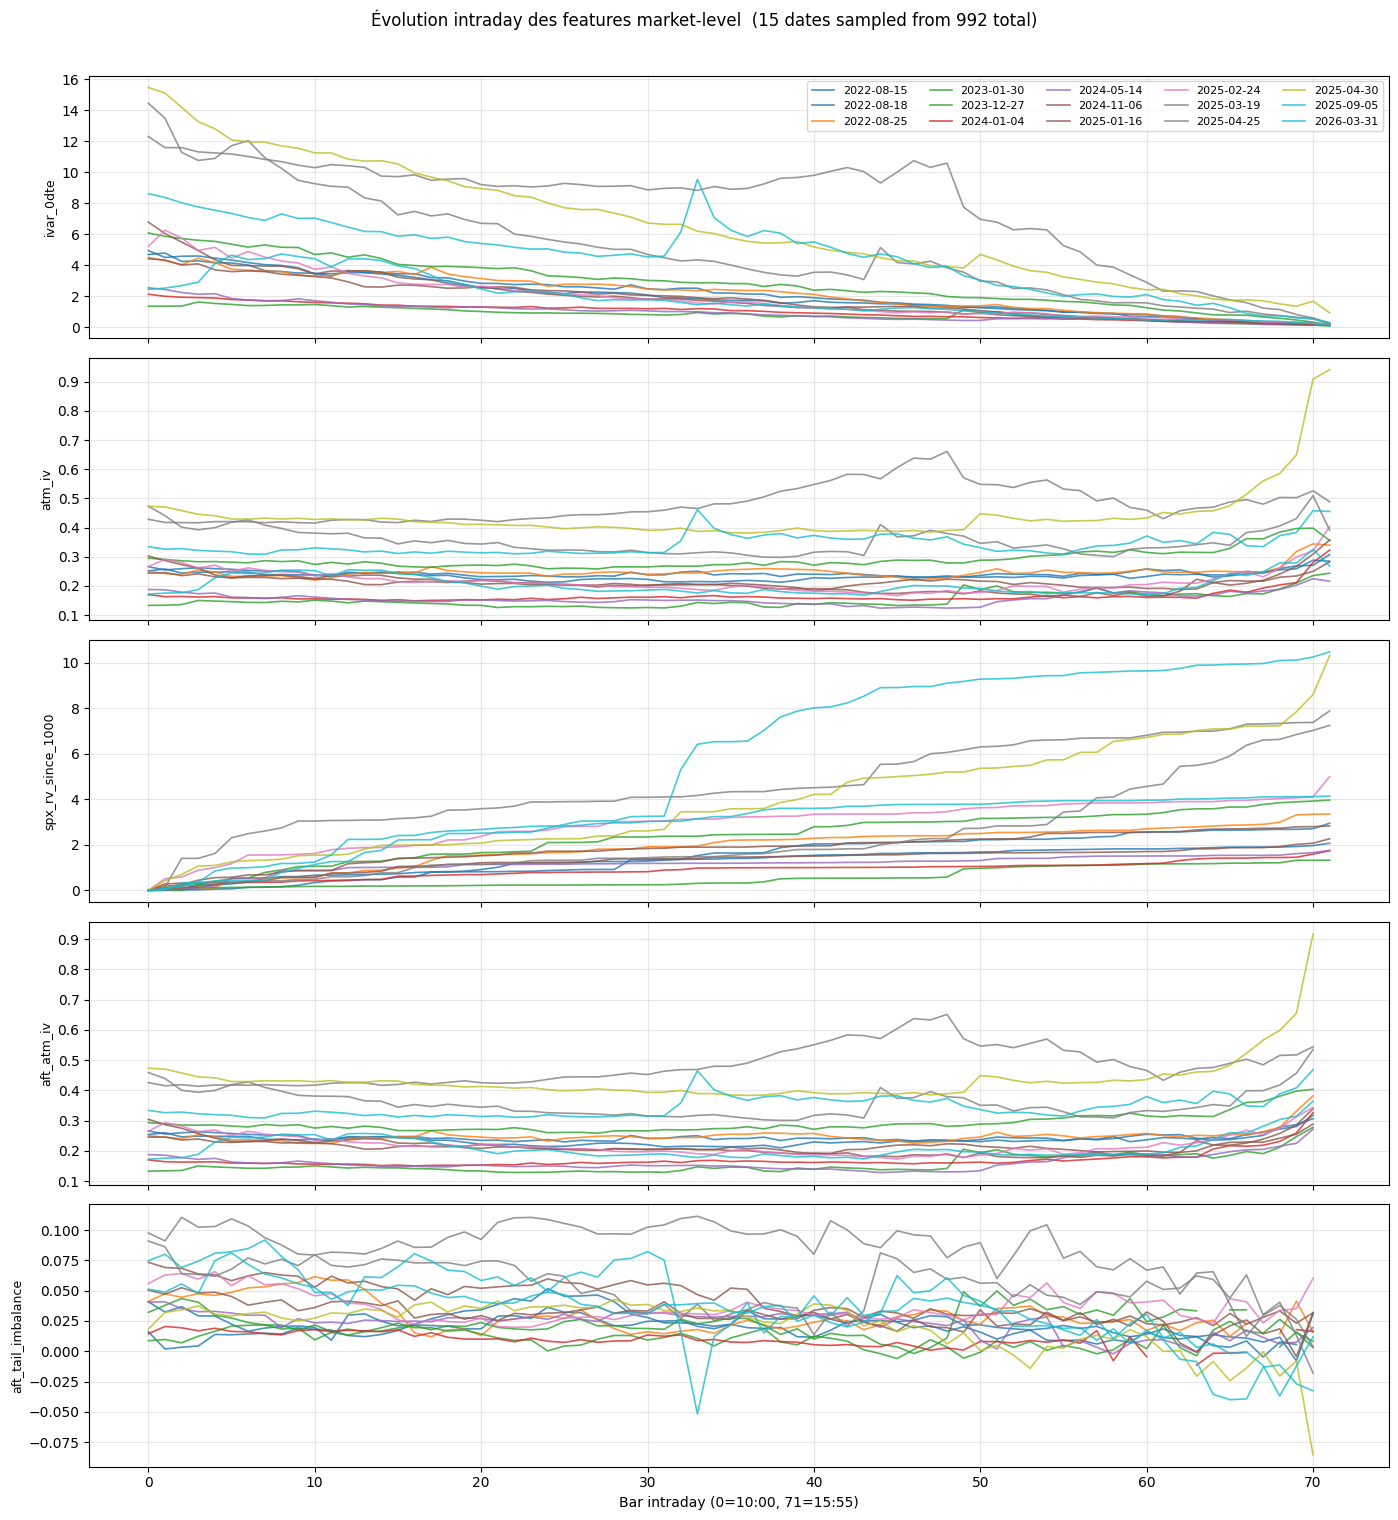

In [21]:
market_feats = ["ivar_0dte", "atm_iv", "spx_rv_since_1000", "aft_atm_iv", "aft_tail_imbalance"]
market_feats = [f for f in market_feats if f in df.columns]

# Une valeur par (date, time) — market-level donc identique pour toutes les stratégies
ts = (
    df.groupby(["quote_date", "quote_time"])[market_feats]
    .first()
    .reset_index()
)
ts["bar"] = ts.groupby("quote_date").cumcount()

all_dates = sorted(ts["quote_date"].unique())
# Cap at 15 dates: 992 overlapping lines is unreadable and causes legend overflow
MAX_DATES = 15
if len(all_dates) > MAX_DATES:
    rng = np.random.default_rng(42)
    plot_dates = sorted(rng.choice(all_dates, MAX_DATES, replace=False).tolist())
    subtitle = f"({MAX_DATES} dates sampled from {len(all_dates)} total)"
else:
    plot_dates = all_dates
    subtitle = f"({len(all_dates)} dates)"

colors = plt.cm.tab10(np.linspace(0, 1, len(plot_dates)))

fig, axes = plt.subplots(len(market_feats), 1, figsize=(14, 3 * len(market_feats)), sharex=True)
if len(market_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, market_feats):
    for date, color in zip(plot_dates, colors):
        sub = ts[ts["quote_date"] == date].sort_values("bar")
        ax.plot(sub["bar"], sub[feat], label=str(pd.Timestamp(date).date()),
                color=color, alpha=0.8, lw=1.2)
    ax.set_ylabel(feat, fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Bar intraday (0=10:00, 71=15:55)")
# ncol capped — never let matplotlib lay out hundreds of legend entries in one row
axes[0].legend(loc="upper right", fontsize=8, ncol=min(len(plot_dates), 5))
plt.suptitle(f"Évolution intraday des features market-level  {subtitle}", y=1.01)
plt.tight_layout()
plt.show()

## 6. CS z-scores — vérification cross-sectionelle à 10:00

CS z-scores à 10:00 (37 colonnes, 992 dates) :
  mean(mean) = 0.0000  (attendu ≈ 0)
  mean(std)  = 1.0000  (attendu ≈ 1)
  max|mean|  = 0.0000
  Toutes les colonnes ont |mean| ≤ 0.05 ✓


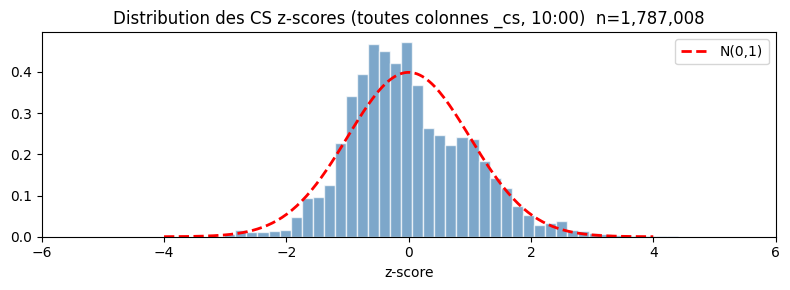

In [24]:
# Vérifier que les _cs features ont bien mean≈0 et std≈1 dans la cross-section
cs_cols = [c for c in feat_cols if c.endswith("_cs") and not c.endswith("_cs_family")]
d10 = df[df["quote_time"] == "10:00"]

cs_means = d10.groupby("quote_date")[cs_cols].mean()
cs_stds  = d10.groupby("quote_date")[cs_cols].std()

# Certaines _cs ont des NaN (groupe trop petit, ou feature source toute NaN) → nanmean
print(f"CS z-scores à 10:00 ({len(cs_cols)} colonnes, {d10['quote_date'].nunique()} dates) :")
print(f"  mean(mean) = {np.nanmean(cs_means.values):.4f}  (attendu ≈ 0)")
print(f"  mean(std)  = {np.nanmean(cs_stds.values):.4f}  (attendu ≈ 1)")
print(f"  max|mean|  = {np.nanmax(np.abs(cs_means.values)):.4f}")

# Colonnes avec mean non nulle (potentiel problème)
col_means = cs_means.mean()  # moyenne sur les dates
bad = col_means[col_means.abs() > 0.05].sort_values(key=abs, ascending=False)
if len(bad):
    print(f"\n  Colonnes avec |mean| > 0.05 :")
    print(bad.to_string())
else:
    print("  Toutes les colonnes ont |mean| ≤ 0.05 ✓")

# Distribution des z-scores
fig, ax = plt.subplots(figsize=(8, 3))
vals = d10[cs_cols].values.flatten()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=60, color="steelblue", density=True, edgecolor="white", alpha=0.7)
x = np.linspace(-4, 4, 200)
ax.plot(x, np.exp(-0.5*x**2) / np.sqrt(2*np.pi), "r--", lw=2, label="N(0,1)")
ax.set_xlim(-6, 6)
ax.set_title(f"Distribution des CS z-scores (toutes colonnes _cs, 10:00)  n={len(vals):,}")
ax.set_xlabel("z-score")
ax.legend()
plt.tight_layout()
plt.show()

## 7. No-lookahead check — PnL lag

In [11]:
# Vérifier que pnl_lag1_same_time[date d, time t] == target_y_long_net[date d-1, time t]
# pour une stratégie donnée

strat_check = "strangle"
mnes_check  = df[df["option_type"] == strat_check]["mnes"].value_counts().index[0]
time_check  = "10:00"

sub = (
    df[(df["option_type"] == strat_check) & (df["mnes"] == mnes_check) & (df["quote_time"] == time_check)]
    .sort_values("quote_date")[["quote_date", "pnl_lag1_same_time", "target_y_long_net"]]
    .reset_index(drop=True)
)

# pnl_lag1[row i] should equal target_y_long_net[row i-1]
sub["expected_lag1"] = sub["target_y_long_net"].shift(1)
sub["lag_correct"]   = np.isclose(sub["pnl_lag1_same_time"], sub["expected_lag1"], equal_nan=True)

print(f"Strategy: {strat_check}  mnes: {mnes_check}  time: {time_check}")
display(sub)

n_valid = sub["lag_correct"].dropna().sum()
n_total = sub["lag_correct"].notna().sum()
status = "✓ PASS" if n_valid == n_total else "✗ FAIL"
print(f"\nNo-lookahead lag check: {status}  ({n_valid}/{n_total} rows correct)")

Strategy: strangle  mnes: 0.985/1.015  time: 10:00


,quote_date,pnl_lag1_same_time,target_y_long_net,expected_lag1,lag_correct
0,2022-04-01,NaN,-0.0002,NaN,True
1,2022-04-04,-0.0002,-0.0001,-0.0002,True
2,2022-04-06,-0.0001,-0.0005,-0.0001,True
3,2022-04-08,-0.0005,-0.0004,-0.0005,True
4,2022-04-11,-0.0004,-0.0002,-0.0004,True
...,...,...,...,...,...
987,2026-05-04,-0.0001,-0.0001,-0.0001,True
988,2026-05-05,-0.0001,-0.0001,-0.0001,True
989,2026-05-06,-0.0001,-0.0001,-0.0001,True
990,2026-05-07,-0.0001,-0.0001,-0.0001,True



No-lookahead lag check: ✓ PASS  (992/992 rows correct)


## 8. Feature sets — colonnes présentes dans le parquet

In [25]:
parquet_cols = set(df.columns)
rows = []
for fam, cols in FAMILIES.items():
    present = [c for c in cols if c in parquet_cols]
    absent  = [c for c in cols if c not in parquet_cols]
    rows.append({
        "famille": fam,
        "total": len(cols),
        "présent": len(present),
        "absent": len(absent),
        "colonnes absentes": ", ".join(absent[:3]) + (" ..." if len(absent) > 3 else ""),
    })

fam_df = pd.DataFrame(rows).set_index("famille")
print(fam_df)

# Colonnes demandées par get_feature_cols("all") mais absentes du parquet
all_wanted = get_feature_cols("all")
missing_from_parquet = [c for c in all_wanted if c not in parquet_cols]
if missing_from_parquet:
    print(f"\n⚠ {len(missing_from_parquet)} colonnes dans feature_sets.py absentes du parquet:")
    for c in missing_from_parquet[:20]:
        print(f"  {c}")
else:
    print("\n✓ Toutes les colonnes de get_feature_cols('all') sont présentes dans le parquet")

                 total  présent  absent colonnes absentes
famille                                                  
vilkov_baseline     10       10       0                  
liquidity           14       14       0                  
strategy_price      15       15       0                  
greeks              15       15       0                  
flow                21       21       0                  
gex                  4        4       0                  
spx_intraday        20       20       0                  
implied             25       25       0                  
aft                 18       18       0                  
lagged_realized      6        6       0                  
pnl_lags            10       10       0                  
payoff_shape         9        9       0                  
macro               13       13       0                  
iv_rv_ratio          3        3       0                  
dummies              9        9       0                  
cs_scaled     

## 9. Corrélation des features — identification des redondances

Objectif : repérer les groupes très corrélés avant la sélection du baseline model.

- Calcul sur le bar 10:00 uniquement (évite l'autocorrélation intraday)
- Toutes les 64 stratégies incluses (garde la variabilité cross-sectionelle)
- Exclusion des colonnes `_sqtr` (doublons systématiques de leur colonne source)

Features actives (get_feature_cols('all') ∩ parquet) : 107
Éligibles (NaN<50%, std>0) : 107
Observations : 366,628  (80 dates × toutes barres)
Calcul corrélation Pearson...

Paires avec |ρ| ≥ 0.7 :  101 paires



,feat_A,feat_B,ρ,|ρ|
0,gamma_cs,theta_cs,-0.9763,0.9763
1,vega_S,gamma_cs,0.9633,0.9633
2,vega_S,theta_cs,-0.9588,0.9588
3,strat_vol_lag5_cs,strat_txn_lag5_cs,0.9584,0.9584
4,vilkov_v_cs,strat_vol_lag5_cs,0.9567,0.9567
5,d_sqtr,depth_per_contract_sqtr,0.9443,0.9443
6,gross_entry_premium_cs,gp_per_contract_sqtr,0.9331,0.9331
7,gamma_cs,tv_cs,0.9258,0.9258
8,vilkov_v_cs,strat_txn_lag5_cs,0.9236,0.9236
9,vilkov_v_cs,vilkov_fGamma_cs,0.9173,0.9173


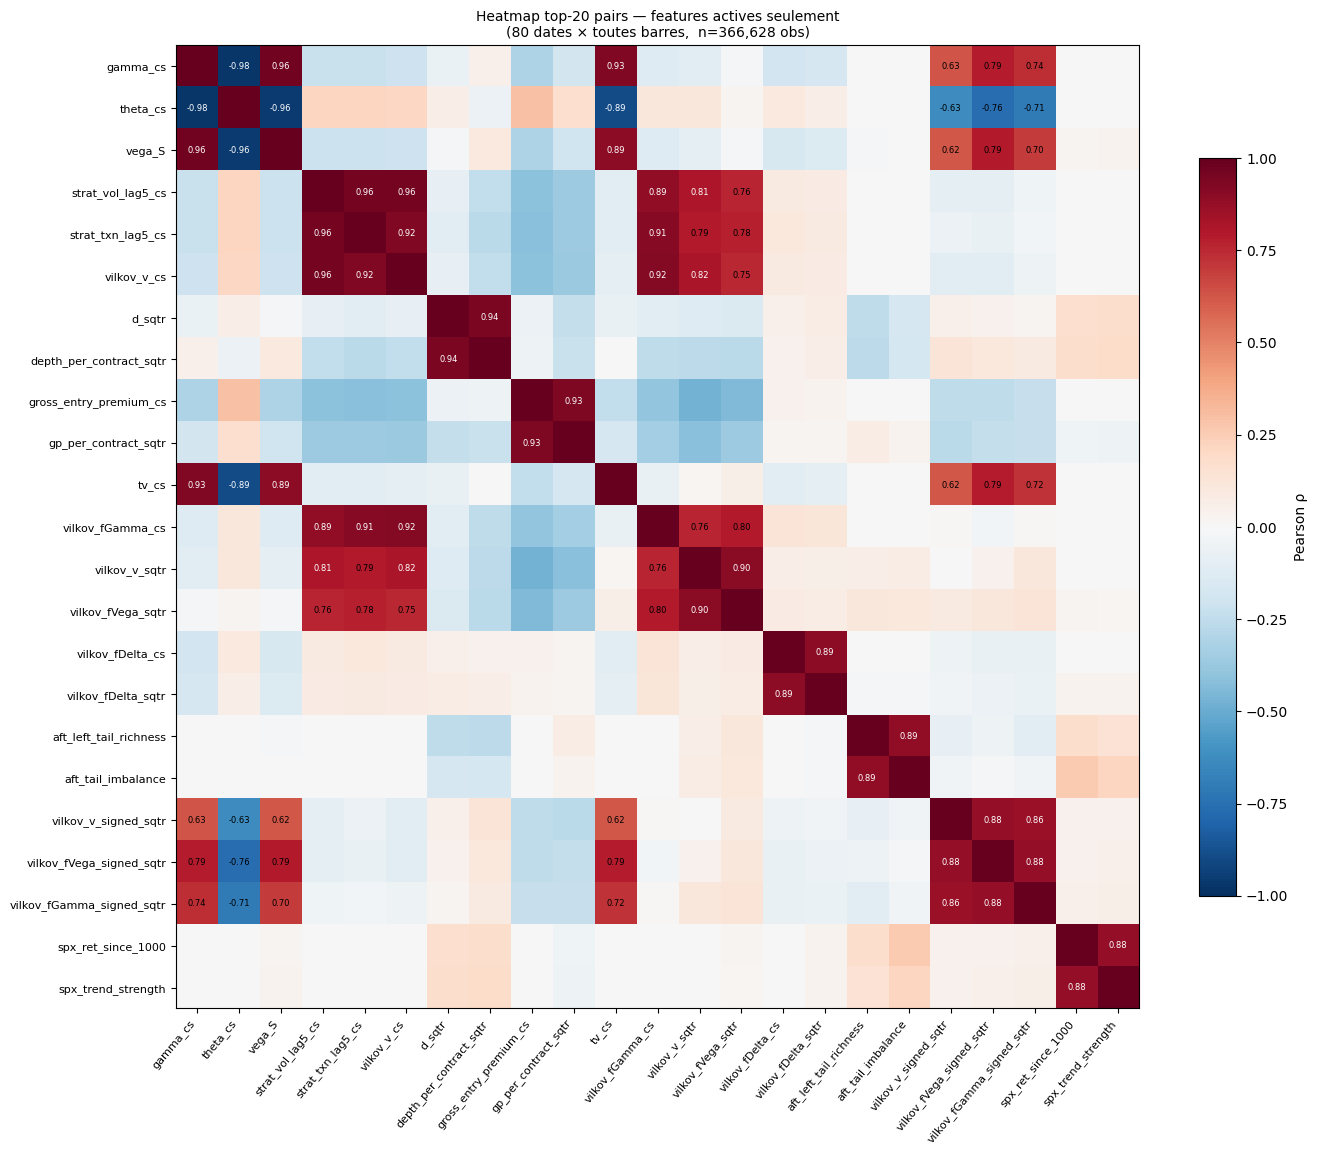


Features dans ≥1 paire avec |ρ| ≥ 0.8  (candidats à commenter) :


,nb_paires_≥0.80
gamma_cs,5
vilkov_v_sqtr,5
theta_cs,5
vega_S,4
strat_vol_lag5_cs,4
vilkov_v_cs,4
vilkov_fGamma_cs,3
vilkov_fGamma_signed_sqtr,3
vilkov_gamma_balance,3
gamma_S,3


In [3]:
# ── Corrélation Pearson — features actives dans feature_sets.py uniquement ────
# On filtre sur get_feature_cols("all") pour ne voir que ce qui sera passé au modèle
# (pas les doublons, pas les [id]/[meta]/[dup] de AVAILABLE_NOT_IN_FAMILIES)

from feature_sets import get_feature_cols

active_cols = [c for c in get_feature_cols("all") if c in df.columns]
print(f"Features actives (get_feature_cols('all') ∩ parquet) : {len(active_cols)}")

N_DATES_SAMPLE = min(df["quote_date"].nunique(), 80)
rng = np.random.default_rng(42)
sampled_dates = rng.choice(df["quote_date"].unique(), N_DATES_SAMPLE, replace=False)
df_corr = df[df["quote_date"].isin(sampled_dates)].copy()

# Features éligibles parmi les actives : NaN < 50%, variance > 0
elig = [
    c for c in active_cols
    if df_corr[c].isna().mean() < 0.5
    and df_corr[c].std(skipna=True) > 1e-10
]
print(f"Éligibles (NaN<50%, std>0) : {len(elig)}")
print(f"Observations : {len(df_corr):,}  ({N_DATES_SAMPLE} dates × toutes barres)")
print("Calcul corrélation Pearson...")

corr = df_corr[elig].corr()

# ── DataFrame pairs triés par |ρ| décroissant ────────────────────────────────
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
all_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feat_A", "level_1": "feat_B", 0: "ρ"})
    .assign(**{"|ρ|": lambda x: x["ρ"].abs()})
    .sort_values("|ρ|", ascending=False)
    .reset_index(drop=True)
)

DISPLAY_THRESH = 0.70
to_display = all_pairs[all_pairs["|ρ|"] >= DISPLAY_THRESH][["feat_A", "feat_B", "ρ", "|ρ|"]].round(4)
print(f"\nPaires avec |ρ| ≥ {DISPLAY_THRESH} :  {len(to_display)} paires\n")
pd.set_option("display.max_rows", 300)
display(to_display)
pd.reset_option("display.max_rows")

# ── Heatmap des features impliquées dans le top-20 ───────────────────────────
hot = pd.unique(all_pairs.head(20)[["feat_A", "feat_B"]].values.ravel()).tolist()
hot = [f for f in hot if f in corr.index][:32]
sub = corr.loc[hot, hot]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sub.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(hot)))
ax.set_yticks(range(len(hot)))
ax.set_xticklabels(hot, rotation=50, ha="right", fontsize=8)
ax.set_yticklabels(hot, fontsize=8)
for i in range(len(hot)):
    for j in range(len(hot)):
        v = sub.values[i, j]
        if abs(v) > 0.55 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if abs(v) > 0.8 else "black")
plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson ρ")
ax.set_title(
    f"Heatmap top-20 pairs — features actives seulement\n"
    f"({N_DATES_SAMPLE} dates × toutes barres,  n={len(df_corr):,} obs)",
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Features dans ≥1 paire avec |ρ| ≥ 0.80 ───────────────────────────────────
THRESH = 0.80
high = all_pairs[all_pairs["|ρ|"] >= THRESH]
if len(high):
    counts = pd.concat([high["feat_A"], high["feat_B"]]).value_counts().head(25)
    print(f"\nFeatures dans ≥1 paire avec |ρ| ≥ {THRESH}  (candidats à commenter) :")
    display(counts.rename("nb_paires_≥0.80").to_frame())
else:
    print(f"\nAucune paire avec |ρ| ≥ {THRESH}.")

In [4]:
df

,quote_date,quote_time,option_type,mnes,quote_dt,S,M,mid,tv,intrinsic,gross_entry_premium,bas,h,fee,rho,d,delta,gamma,vega,theta,iv_mean,n_legs,n_contracts,turnover,snap_error_max,snap_error_mean,abs_mid,premium_abs,net_premium,half_spread_bps,...,strat_vol_lag30_sqtr,strat_vol_lag5_sqtr,strat_vol_lag5_cs_sqtr,strat_vol_since_open_sqtr,vilkov_fDelta_sqtr,vilkov_fDelta_cs_sqtr,vilkov_fDelta_lag30_sqtr,vilkov_fDelta_lag30_signed_sqtr,vilkov_fDelta_signed_sqtr,vilkov_fGamma_sqtr,vilkov_fGamma_cs_sqtr,vilkov_fGamma_lag30_sqtr,vilkov_fGamma_lag30_signed_sqtr,vilkov_fGamma_signed_sqtr,vilkov_fVega_sqtr,vilkov_fVega_cs_sqtr,vilkov_fVega_lag30_sqtr,vilkov_fVega_lag30_signed_sqtr,vilkov_fVega_signed_sqtr,vilkov_txn_sqtr,vilkov_txn_cum_sqtr,vilkov_txn_cum_signed_sqtr,vilkov_txn_signed_sqtr,vilkov_v_sqtr,vilkov_v_cs_sqtr,vilkov_v_cum_sqtr,vilkov_v_cum_signed_sqtr,vilkov_v_lag30_sqtr,vilkov_v_lag30_signed_sqtr,vilkov_v_signed_sqtr
0,2022-04-01,10:00,bear_put_spread,0.975/1,2022-04-01 10:00:00,4539.3500,0.9875,0.0030,0.0029,0.0001,0.0030,0.0002,0.0001,0.0000,0.5292,469.0000,-0.4997,0.0115,0.4520,-25.0166,0.3380,2,2,0.3139,0.0191,0.0167,0.0030,0.0030,0.0030,0.9913,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-04-01,10:00,bear_put_spread,0.975/1.025,2022-04-01 10:00:00,4539.3500,1.0001,0.0257,0.0002,0.0255,0.0257,0.0026,0.0013,0.0000,0.5493,533.0000,-0.9546,0.0009,0.0780,-9.1153,0.4682,2,2,2.6997,0.0477,0.0334,0.0257,0.0257,0.0257,12.7772,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-04-01,10:00,bear_put_spread,0.98/1,2022-04-01 10:00:00,4539.3500,0.9902,0.0030,0.0028,0.0001,0.0031,0.0002,0.0001,0.0000,0.3625,490.0000,-0.4952,0.0112,0.4393,-24.4420,0.3073,2,2,0.3150,0.0317,0.0230,0.0030,0.0030,0.0030,0.9913,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-04-01,10:00,bear_put_spread,0.98/1.02,2022-04-01 10:00:00,4539.3500,1.0001,0.0199,-0.0000,0.0200,0.0200,0.0010,0.0005,0.0000,0.3576,484.0000,NaN,NaN,NaN,NaN,0.3325,2,2,2.0488,0.0317,0.0173,0.0199,0.0199,0.0199,4.9567,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-04-01,10:00,bear_put_spread,0.985/1,2022-04-01 10:00:00,4539.3500,0.9924,0.0029,0.0028,0.0001,0.0031,0.0002,0.0001,0.0000,0.1721,116.0000,-0.4806,0.0102,0.4030,-22.4521,0.2923,2,2,0.3194,0.0278,0.0210,0.0029,0.0029,0.0029,0.9913,...,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4562605,2026-05-08,15:55,strangle,0.975/1.025,2026-05-08 15:55:00,7397.3875,0.9997,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,905.0000,NaN,NaN,NaN,NaN,NaN,2,2,0.0000,0.0332,0.0323,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,-0.9378,51.9326,0.0000,0.0542,0.0000,0.0000,0.0000,0.0000,-0.9327,0.0000,0.0000,0.0000,0.0000,-0.9323,0.0000,0.0000,0.0000,0.0000,35.6511,35.6511,0.0000,0.0000,-0.9439,67.4611,67.4611,0.0000,0.0000,0.0000
4562606,2026-05-08,15:55,strangle,0.98/1.02,2026-05-08 15:55:00,7397.3875,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,754.0000,NaN,NaN,NaN,NaN,NaN,2,2,0.0000,0.0076,0.0061,0.0000,0.0000,0.0000,0.0000,...,4.0000,0.0000,-0.9378,78.5239,0.0000,0.0542,0.0000,0.0000,0.0000,0.0000,-0.9327,0.0000,0.0000,0.0000,0.0000,-0.9323,0.0000,0.0000,0.0000,1.0000,51.1371,51.1371,1.0000,1.0000,-0.9438,94.8051,94.8051,4.1231,4.1231,1.0000
4562607,2026-05-08,15:55,strangle,0.985/1.015,2026-05-08 15:55:00,7397.3875,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,N

In [10]:
df[df['all_liquid_int'] == 0][['n_contracts']].value_counts()

<bound method DataFrame.value_counts of          n_contracts
10                 2
19                 2
23                 3
32                 3
33                 4
...              ...
4562605            2
4562606            2
4562607            2
4562608            2
4562609            2

[1788393 rows x 1 columns]>